In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [ ]:
le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy :", lr_accuracy)

In [ ]:
lr_precision = precision_score(y_test, lr_pred)

print("Precision :", lr_precision)

In [ ]:
lr_recall = recall_score(y_test, lr_pred)

print("Recall :", lr_recall)

In [ ]:
lr_f1 = f1_score(y_test, lr_pred)

print("F1 Score :", lr_f1)

In [ ]:
lr_prob = lr.predict_proba(X_test)[:,1]

lr_roc = roc_auc_score(y_test, lr_prob)

print("ROC AUC :", lr_roc)

In [ ]:
print(classification_report(y_test, lr_pred))

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)

In [ ]:
rf_precision = precision_score(y_test, rf_pred)

print("Precision :", rf_precision)

In [ ]:
rf_recall = recall_score(y_test, rf_pred)

print("Recall :", rf_recall)

In [ ]:
rf_f1 = f1_score(y_test, rf_pred)

print("F1 Score :", rf_f1)

In [ ]:
rf_prob = rf.predict_proba(X_test)[:,1]

rf_roc = roc_auc_score(y_test, rf_prob)

print("ROC AUC :", rf_roc)

In [ ]:
print(classification_report(y_test, rf_pred))

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
lr_cv = cross_val_score(
    lr,
    X_scaled,
    y,
    cv=5
)

print("LR Cross Validation Mean :", lr_cv.mean())

In [ ]:
rf_cv = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5
)

print("RF Cross Validation Mean :", rf_cv.mean())

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")

plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy
    ],

    "Precision":[
        lr_precision,
        rf_precision
    ],

    "Recall":[
        lr_recall,
        rf_recall
    ],

    "F1 Score":[
        lr_f1,
        rf_f1
    ],

    "ROC-AUC":[
        lr_roc,
        rf_roc
    ]
})

results

In [ ]:
importance = rf.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({

    "Feature":feature_names,
    "Importance":importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df.head(10)

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
import pickle

pickle.dump(rf, open("churn_model.pkl","wb"))

Random Forest performed better than Logistic Regression
because it achieved higher Accuracy, F1-score, and ROC-AUC.

The most important features affecting churn were:
- Contract Type
- Monthly Charges
- Tenure

This model can help telecom companies identify customers
likely to leave and take preventive actions.

In [ ]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
pip install shap lime

In [ ]:
import shap
import lime
import lime.lime_tabular

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
explainer = shap.TreeExplainer(rf)

In [ ]:
shap_values = explainer.shap_values(X_test)

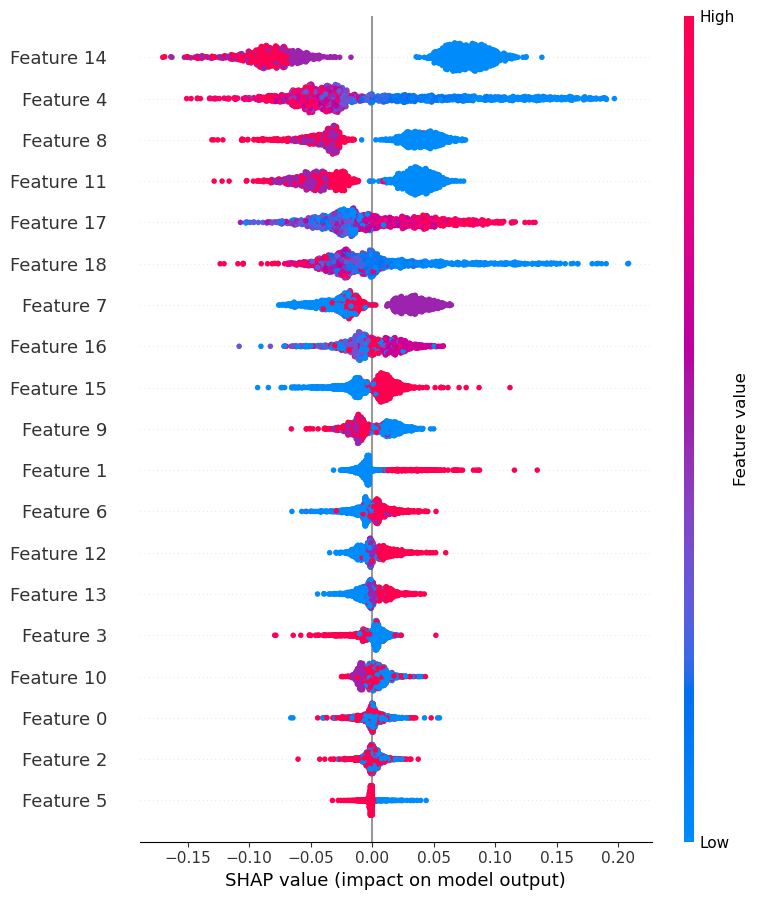

In [91]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

In [96]:
sample = X_test[0]

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

In [99]:
male_data = df[df['gender'] == 'Male']

female_data = df[df['gender'] == 'Female']

In [100]:
print(male_data['Churn'].mean())

print(female_data['Churn'].mean())

nan
nan


In [102]:
print(df['gender'].unique())

[0 1]


In [104]:
male_data = df[df['gender'] == 1]

female_data = df[df['gender'] == 0]

In [105]:
print(male_data['Churn'].mean())

print(female_data['Churn'].mean())

0.26204564666103125
0.2695951765719208


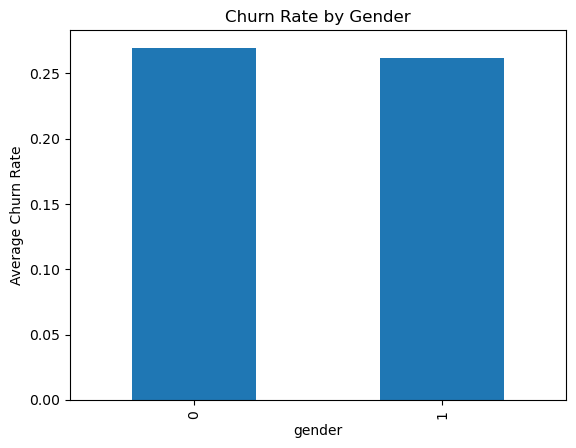

In [106]:
grouped = df.groupby('gender')['Churn'].mean()

grouped.plot(kind='bar')

plt.title("Churn Rate by Gender")

plt.ylabel("Average Churn Rate")

plt.show()

In [107]:
df.groupby('SeniorCitizen')['Churn'].mean()

SeniorCitizen
0    0.236503
1    0.416813
Name: Churn, dtype: float64

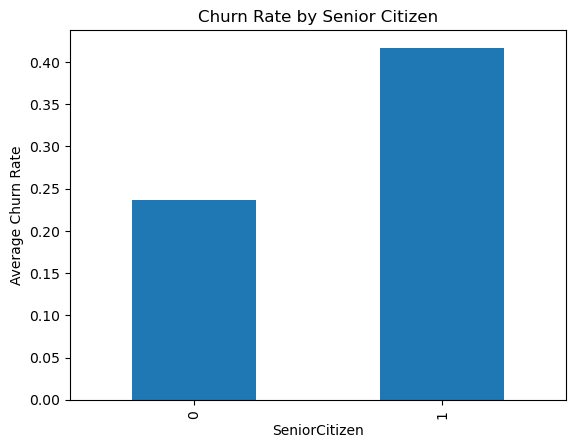

In [108]:
df.groupby('SeniorCitizen')['Churn'].mean().plot(kind='bar')

plt.title("Churn Rate by Senior Citizen")

plt.ylabel("Average Churn Rate")

plt.show()